In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import missingno as msno
from icecream import ic
import seaborn as sns

In [4]:
filename = r"../../data/raw/term-deposit-marketing-2020.csv"
df = pd.read_csv(filename)

# Numerical Correlations

In [ ]:
num_df = df.select_dtypes(include=['number'])
num_df

### Pearson correlation

[Text(0.5, 1.0, 'Pearson Correlation Matrix (Numerical to Numerical, assuming normality)')]

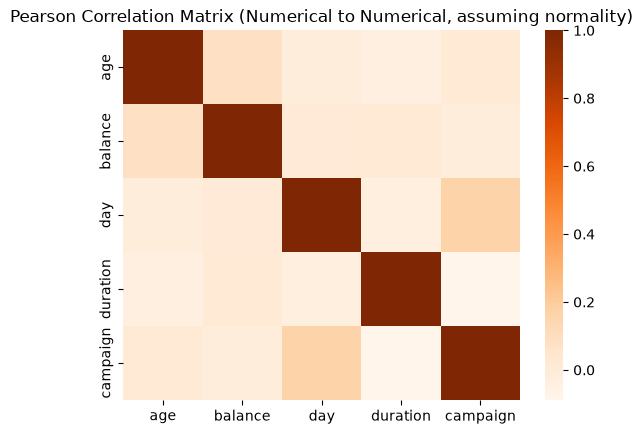

In [ ]:
pearson_corr_matrix = num_df.corr()
sns.heatmap(pearson_corr_matrix, cmap="Oranges",).set(title="Pearson Correlation Matrix (Numerical to Numerical, assuming normality)")

### Spearman correlation (will find non-linear correlations)

[Text(0.5, 1.0, 'Spearman Ascociation Matrix (Numerical to Numerical)')]

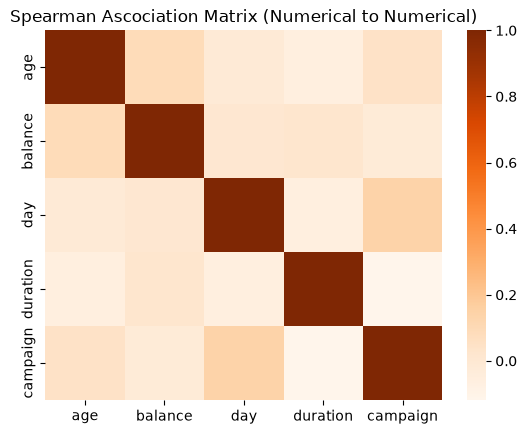

In [69]:
spearman_corr_matrix = num_df.corr(method='spearman')
sns.heatmap(spearman_corr_matrix, cmap="Oranges",).set(title="Spearman Ascociation Matrix (Numerical to Numerical)")

# Categorical Correlations

In [41]:
cat_df = df.select_dtypes(include=['object', 'category', 'str'])
binary_cat_df = cat_df.loc[:,[col for col in cat_df.columns if len(cat_df[col].unique()) == 2]]
binary_cat_df

,default,housing,loan,y
0,no,yes,no,no
1,no,yes,no,no
2,no,yes,yes,no
3,no,yes,no,no
4,no,no,no,no
...,...,...,...,...
39995,no,no,no,no
39996,no,no,no,yes
39997,no,no,no,yes
39998,no,no,no,no


In [44]:
multiclass_cat_df = cat_df.loc[:,[col for col in cat_df.columns if col not in binary_cat_df.columns]]
multiclass_cat_df

,job,marital,education,contact,month
0,management,married,tertiary,unknown,may
1,technician,single,secondary,unknown,may
2,entrepreneur,married,secondary,unknown,may
3,blue-collar,married,unknown,unknown,may
4,unknown,single,unknown,unknown,may
...,...,...,...,...,...
39995,technician,married,tertiary,cellular,jun
39996,management,single,tertiary,cellular,jun
39997,admin,divorced,secondary,cellular,jun
39998,management,married,tertiary,cellular,jun


### Cramer's V statistic

In [32]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x,y):
    confusion_matrix = pd.crosstab(x,y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

cramers_matrix = pd.DataFrame(index=cat_df.columns, columns= cat_df.columns)
for col1 in cat_df.columns:
    for col2 in cat_df.columns:
        cramers_matrix.loc[col1,col2] = cramers_v(cat_df[col1], cat_df[col2])

In [38]:
cramers_matrix.dtypes

job          object
marital      object
education    object
default      object
housing      object
loan         object
contact      object
month        object
y            object
dtype: object

[Text(0.5, 1.0, "Cramer's V")]

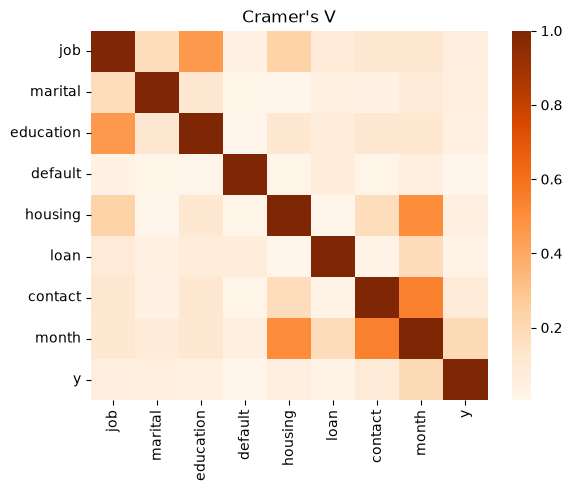

In [63]:
sns.color_palette("Oranges", as_cmap=True)
sns.heatmap(cramers_matrix.astype(float), cmap="Oranges",).set(title="Cramer's V")

### Categorical to Numerical Correlation

Point-Biserial (Binary Categorical)

[Text(0.5, 1.0, 'Point-Biserial')]

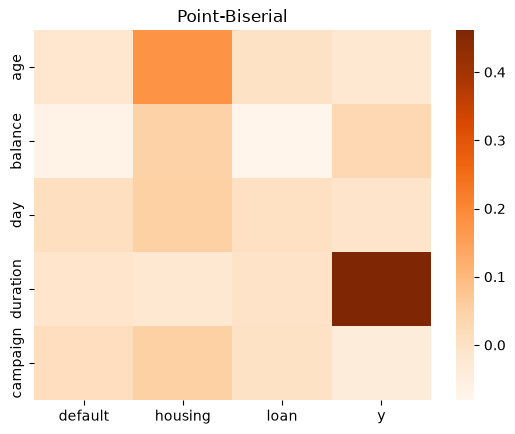

In [66]:
from scipy.stats import pointbiserialr
biserial_corr = {cat_col : {} for cat_col in binary_cat_df}
# print(biserial_corr)
for cat_col in binary_cat_df:
    for num_col in num_df:
        cat_binary_for_col = pd.factorize(binary_cat_df[cat_col])[0]
        biserial_corr[cat_col][num_col] = pointbiserialr(cat_binary_for_col, num_df[num_col])[0]
sns.heatmap(pd.DataFrame(biserial_corr), cmap="Oranges",).set(title="Point-Biserial")

Correlation Ratio (Multi-class Categorical)

In [57]:
def correlation_ratio(categories, measurements):
    categories = pd.factorize(categories)[0]
    categories = np.array(categories)
    measurements = np.array(measurements)

    fcat, _ = pd.factorize(categories)
    cat_num = np.max(fcat) + 1
    y_avg_total = np.mean(measurements)
    numerator = np.sum(((np.array([measurements[np.argwhere(fcat==i)].mean()
                                                for i in range(0,cat_num)]) - y_avg_total) **2) 
                                                * np.bincount(fcat))
    denominator = np.sum((measurements - y_avg_total) ** 2)
    eta = np.sqrt(numerator / denominator) if denominator != 0 else 0
    return eta

[Text(0.5, 1.0, 'Correlation Ratio (Multiclass Categorial to Numerical)')]

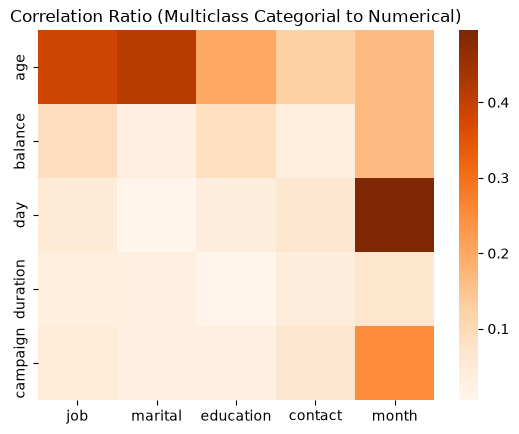

In [67]:
eta_dict = {cat:{} for cat in multiclass_cat_df.columns}
for cat in multiclass_cat_df.columns:
    for num in num_df.columns:
        ratio = correlation_ratio(multiclass_cat_df[cat], num_df[num])
        eta_dict[cat][num] = ratio
        # ic(cat, num, ratio)
sns.heatmap(pd.DataFrame(eta_dict), cmap="Oranges",).set(title="Correlation Ratio (Multiclass Categorial to Numerical)")